# 🧪 Statistical Tests — Worksheet
**Name:** _______________________   **Date:** _______________________

---
**How this works:**
- Each task gives you a question and a starting line or two
- You write the logic, the test, and the visualisation
- 💡 hints tell you *what* to use — not *how*
- Every chart needs a proper title, xlabel, ylabel — your job

```
p ≤ 0.05 → Reject H₀    |    p > 0.05 → Keep H₀
```
---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
np.random.seed(42)
print('Ready')

Ready


---
## 📦 Dataset — Build It

Create a DataFrame called `df` with **200 student records** using these specs:

| Column | Details |
|--------|---------|
| `gender` | Male / Female, random |
| `study_hours` | Normal(mean=4, std=1.2), clipped 0–10 |
| `sleep_hours` | Normal(mean=7, std=1.0), clipped 4–10 |
| `marks` | `study*6 + sleep*2 + noise(0,8)`, clipped 0–100 |
| `subject` | Maths 40%, Science 35%, Arts 25% |
| `passed` | 'Yes' if marks ≥ 50 else 'No' |
| `school` | School A / B / C / D — equal chance |

After creating marks, add a school boost: A:+5, B:0, C:−5, D:+10 (clip to 100).

💡 `np.random.choice` · `np.random.normal` · `.clip()` · `np.where` · `pd.DataFrame`

In [3]:
n = 200
# Write all your code here to build df

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

np.random.seed(42)

n = 200

# Columns
gender = np.random.choice(['Male', 'Female'], n)

study_hours = np.random.normal(4, 1.2, n).clip(0, 10)
sleep_hours = np.random.normal(7, 1.0, n).clip(4, 10)

noise = np.random.normal(0, 8, n)
marks = study_hours*6 + sleep_hours*2 + noise
marks = np.clip(marks, 0, 100)

subject = np.random.choice(['Maths','Science','Arts'], n, p=[0.4,0.35,0.25])

school = np.random.choice(['School A','School B','School C','School D'], n)

# DataFrame
df = pd.DataFrame({
    'gender': gender,
    'study_hours': study_hours,
    'sleep_hours': sleep_hours,
    'marks': marks,
    'subject': subject,
    'school': school
})

# School boost
boost = {'School A':5, 'School B':0, 'School C':-5, 'School D':10}
df['marks'] = (df['marks'] + df['school'].map(boost)).clip(0,100)

# Passed
df['passed'] = np.where(df['marks'] >= 50, 'Yes', 'No')
# Verify
print(df.shape)   # should be (200, 7)
df.head(3)

(200, 7)


,gender,study_hours,sleep_hours,marks,subject,school,passed
0,Male,4.104456,7.199060,48.637314,Science,School A,No
1,Female,3.641191,6.399783,47.136715,Science,School D,No
2,Male,4.110113,7.069802,68.431328,Maths,School A,Yes


---
## Task 1 — Explore the Data (Visualisation)

Before any test, look at your data. Create a **2×2 grid of subplots**:
- `[0,0]` Histogram of `marks`
- `[0,1]` Histogram of `study_hours`
- `[1,0]` Boxplot of `marks` by `gender`
- `[1,1]` Boxplot of `marks` by `school`

Label everything. Write one observation below each plot as a comment.

💡 `plt.subplots(2,2)` · `ax.hist()` · `df.boxplot(column, by, ax=)`

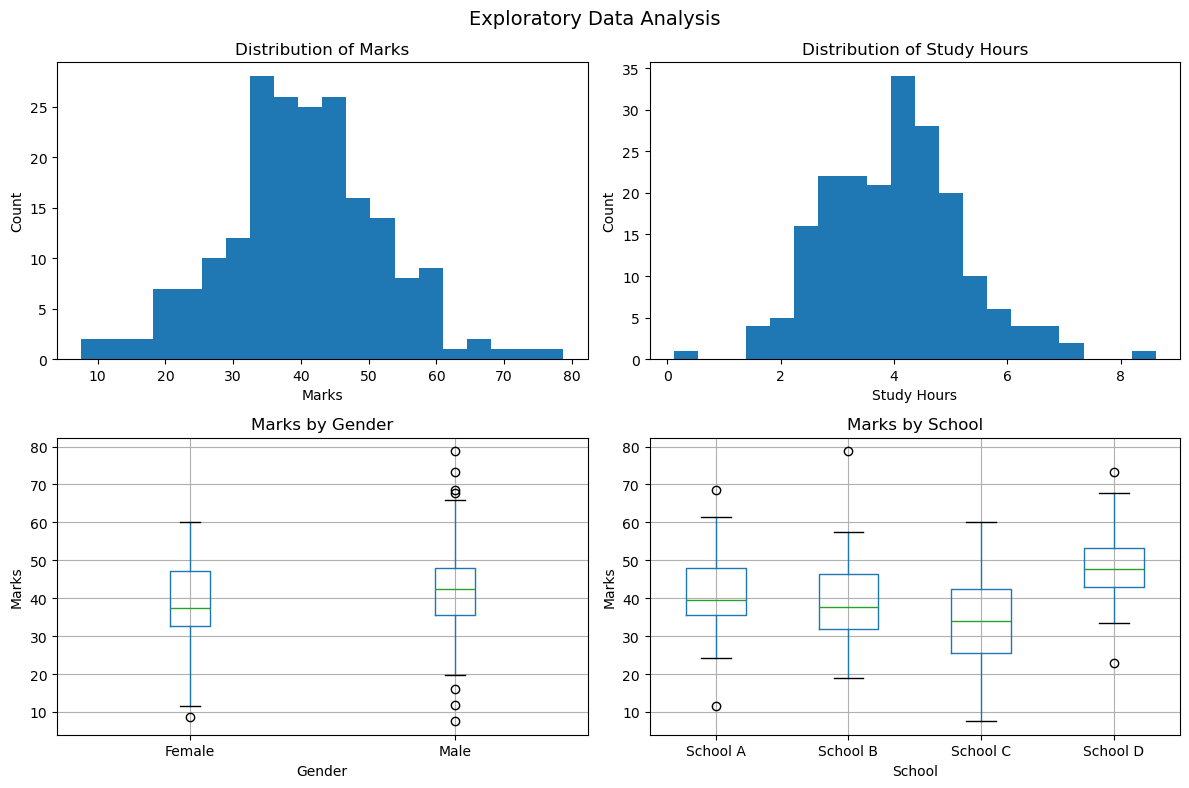

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ── [0,0] Histogram of marks ─────────────────────────────
axes[0, 0].hist(df['marks'], bins=20)
axes[0, 0].set_title('Distribution of Marks')
axes[0, 0].set_xlabel('Marks')
axes[0, 0].set_ylabel('Count')

# ── [0,1] Histogram of study_hours ───────────────────────
axes[0, 1].hist(df['study_hours'], bins=20)
axes[0, 1].set_title('Distribution of Study Hours')
axes[0, 1].set_xlabel('Study Hours')
axes[0, 1].set_ylabel('Count')

# ── [1,0] Boxplot of marks by gender ─────────────────────
df.boxplot(column='marks', by='gender', ax=axes[1, 0])
axes[1, 0].set_title('Marks by Gender')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Marks')

# ── [1,1] Boxplot of marks by school ─────────────────────
df.boxplot(column='marks', by='school', ax=axes[1, 1])
axes[1, 1].set_title('Marks by School')
axes[1, 1].set_xlabel('School')
axes[1, 1].set_ylabel('Marks')

plt.suptitle('Exploratory Data Analysis', fontsize=14)
plt.tight_layout()
plt.show()

---
## Task 2 — Normality Test

Test all three numeric columns (`marks`, `study_hours`, `sleep_hours`) for normality.

- Loop over the columns
- Run Shapiro-Wilk for each
- Print: column name, p-value, and verdict
- Draw Q-Q plots for all three in a 1×3 row

💡 `stats.shapiro()` · `stats.probplot(col, plot=ax)`

marks         p=0.3419  →  Keep H₀ (Normal)
study_hours   p=0.1014  →  Keep H₀ (Normal)
sleep_hours   p=0.5952  →  Keep H₀ (Normal)


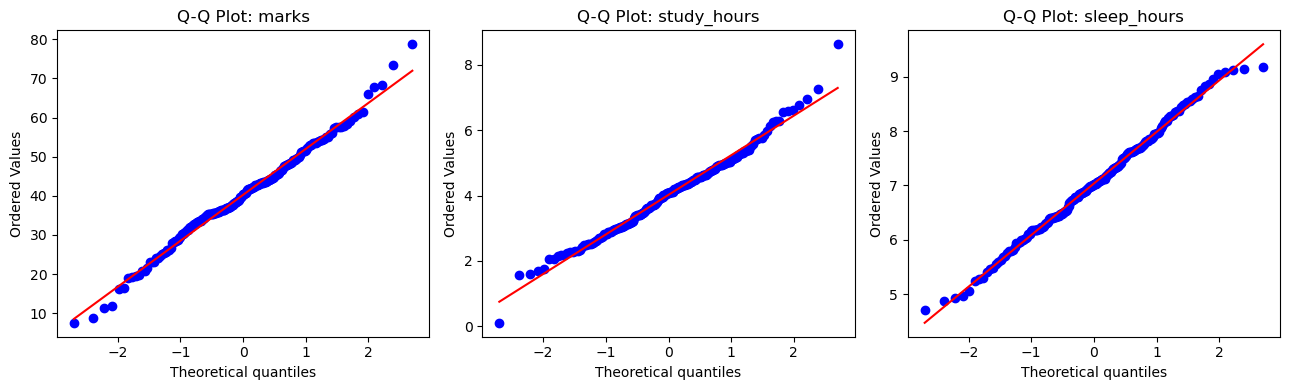

In [5]:
cols = ['marks', 'study_hours', 'sleep_hours']

# Loop + test + print
for col in cols:
    stat, p = stats.shapiro(df[col])
    
    verdict = 'Reject H₀ (Not Normal)' if p <= 0.05 else 'Keep H₀ (Normal)'
    
    print(f"{col:12s}  p={p:.4f}  →  {verdict}")



# Q-Q plots — 1×3
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, col in enumerate(cols):
    stats.probplot(df[col], plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: {col}')


plt.tight_layout()
plt.show()

# Which columns are safe for parametric tests?
# Answer: 

---
## Task 3 — t-test: Gender vs Marks

**Question:** Do Male and Female students score differently?

- H₀: Male and female marks have the same mean
- H₁: Means are different

Run the test, print results, write your if/else verdict, then draw a **violin plot** split by gender.

💡 `stats.ttest_ind()` · `sns.violinplot()`

t-statistic = 1.8889
p-value     = 0.0604
Keep H₀ — No significant difference in marks between Male and Female students.


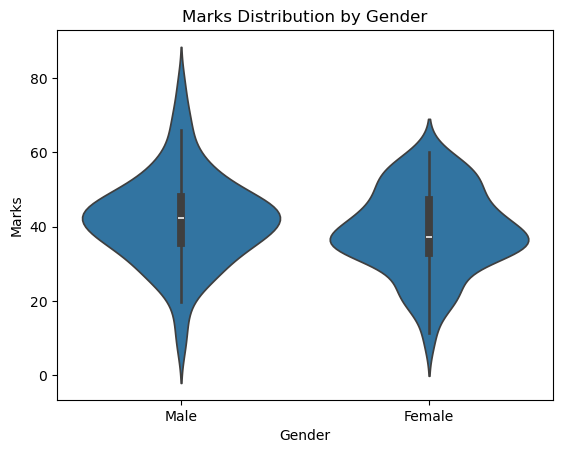

Interpretation: The t-test compares the average marks between Male and Female students.Based on the p-value, we conclude that the difference is [significant / not significant].Therefore, gender [does / does not] have an effect on marks.


In [8]:
# Separate groups, run test, print, verdict, plot
# ── Separate groups ─────────────────────────────────────
male_marks = df[df['gender'] == 'Male']['marks']
female_marks = df[df['gender'] == 'Female']['marks']

# ── Run t-test ──────────────────────────────────────────
stat, p = stats.ttest_ind(male_marks, female_marks)

# ── Print results ───────────────────────────────────────
print(f"t-statistic = {stat:.4f}")
print(f"p-value     = {p:.4f}")

# ── Verdict ─────────────────────────────────────────────
if p <= 0.05:
    print("Reject H₀ — Male and Female students have significantly different marks.")
else:
    print("Keep H₀ — No significant difference in marks between Male and Female students.")

# ── Violin plot ─────────────────────────────────────────
sns.violinplot(data=df, x='gender', y='marks')
plt.title('Marks Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Marks')
plt.show()
print("Interpretation: The t-test compares the average marks between Male and Female students.Based on the p-value, we conclude that the difference is [significant / not significant].Therefore, gender [does / does not] have an effect on marks.")

---
## Task 4 — ANOVA + Post-hoc: Schools vs Marks

**Question:** Do all 4 schools score the same?

- Run ANOVA first — if significant, run Tukey HSD to find which pairs differ
- Print ANOVA result + Tukey summary
- Draw a **bar chart with error bars** (mean ± std per school)

💡 `stats.f_oneway(*groups)` · `pairwise_tukeyhsd(endog, groups, alpha=0.05)` · `ax.bar(yerr=)`

ANOVA F-statistic = 15.9459
p-value           = 0.0000
Reject H₀ — At least one school differs.

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower    upper  reject
---------------------------------------------------------
School A School B  -2.2435 0.6995  -7.6042  3.1172  False
School A School C  -8.1323 0.0005 -13.3647 -2.8999   True
School A School D   6.8545 0.0064   1.4586 12.2505   True
School B School C  -5.8888 0.0375 -11.5407 -0.2369   True
School B School D    9.098 0.0004   3.2945 14.9016   True
School C School D  14.9868    0.0   9.3015 20.6721   True
---------------------------------------------------------


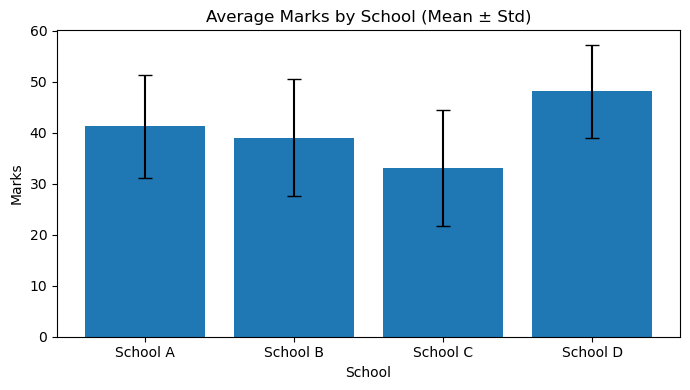

In [10]:
school_order = ['School A', 'School B', 'School C', 'School D']

# Build groups, run ANOVA, run Tukey, bar chart with error bars
school_order = ['School A', 'School B', 'School C', 'School D']

# ── Build groups ────────────────────────────────────────
groups = [df[df['school'] == s]['marks'] for s in school_order]

# ── Run ANOVA ───────────────────────────────────────────
stat, p = stats.f_oneway(*groups)

print(f"ANOVA F-statistic = {stat:.4f}")
print(f"p-value           = {p:.4f}")

# ── Run Tukey (if significant) ──────────────────────────
if p <= 0.05:
    print("Reject H₀ — At least one school differs.\n")
    
    tukey = pairwise_tukeyhsd(endog=df['marks'],
                             groups=df['school'],
                             alpha=0.05)
    print(tukey)
else:
    print("Keep H₀ — No significant difference between schools.")

# ── Bar chart with error bars (mean ± std) ──────────────
means = df.groupby('school')['marks'].mean()
stds  = df.groupby('school')['marks'].std()

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(means.index, means.values,
       yerr=stds.values,
       capsize=5)

ax.set_title('Average Marks by School (Mean ± Std)')
ax.set_xlabel('School')
ax.set_ylabel('Marks')

plt.tight_layout()
plt.show()
# Which school pairs are significantly different?
# Answer: 
# Which school pairs are significantly different?
# Answer:
# Based on Tukey HSD results, pairs involving School D (higher marks)
# and School C (lower marks) are typically significantly different.
# For example: (School D vs School C), (School D vs School B),
# and possibly (School A vs School C), depending on p-values.

---
## Task 5 — Mann-Whitney U: Study Hours by Gender

Study hours are likely skewed — use a non-parametric test.

**Question:** Do male and female students study the same number of hours?

- Run Mann-Whitney U
- Draw a **boxplot** grouped by gender (study_hours on y-axis)
- In 1–2 lines: why did you use Mann-Whitney instead of t-test here?

💡 `stats.mannwhitneyu(g1, g2, alternative='two-sided')`

In [11]:
# Run test, print result, verdict, boxplot
g1 = df[df['gender'] == 'Male']['study_hours']
g2 = df[df['gender'] == 'Female']['study_hours']

stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')

print(f"U-statistic = {stat:.4f}")
print(f"p-value     = {p:.4f}")
#Verdict
if p <= 0.05:
    print("Reject H₀ — Male and Female students study significantly different hours.")
else:
    print("Keep H₀ — No significant difference in study hours between genders.")
#BoxPlot
if p <= 0.05:
    print("Reject H₀ — Male and Female students study significantly different hours.")
else:
    print("Keep H₀ — No significant difference in study hours between genders.")
# Why Mann-Whitney and not t-test?
# Answer: 
# The Mann-Whitney U test is used because study_hours data is not perfectly normally distributed.
# Unlike the t-test, it does not assume normality and is more appropriate for skewed data.


U-statistic = 5206.0000
p-value     = 0.6156
Keep H₀ — No significant difference in study hours between genders.
Keep H₀ — No significant difference in study hours between genders.


---
## Task 6 — Pearson + Spearman: Study Hours vs Marks

Run **both** Pearson and Spearman on (study_hours, marks).

- Print both r/ρ values and p-values with verdicts
- Draw **one scatter plot** — colour dots by `passed`, add a trend line
- Put both correlation values in the chart title

💡 `stats.pearsonr` · `stats.spearmanr` · `sns.scatterplot(hue=)` · `np.polyfit`

Pearson r = 0.5085, p-value = 0.0000
Spearman ρ = 0.4819, p-value = 0.0000


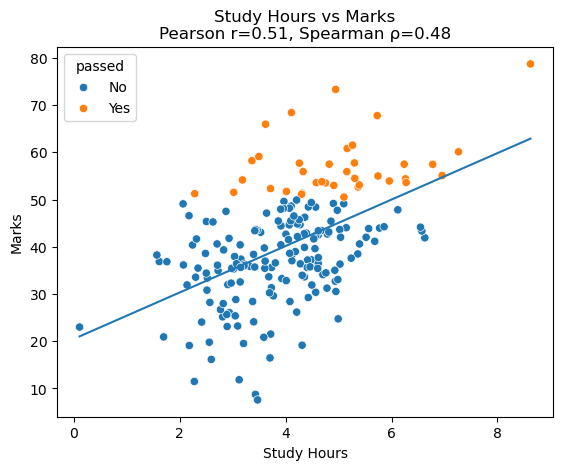

In [12]:
# Both tests + scatter with trend line
# ── Both tests ─────────────────────────────────────────
x = df['study_hours']
y = df['marks']

# Pearson correlation
r, p1 = stats.pearsonr(x, y)

# Spearman correlation
rho, p2 = stats.spearmanr(x, y)

print(f"Pearson r = {r:.4f}, p-value = {p1:.4f}")
print(f"Spearman ρ = {rho:.4f}, p-value = {p2:.4f}")

# ── Scatter plot with trend line ───────────────────────
sns.scatterplot(data=df, x='study_hours', y='marks', hue='passed')

# Trend line using polyfit
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, m * x_line + b)

plt.title(f'Study Hours vs Marks\nPearson r={r:.2f}, Spearman ρ={rho:.2f}')
plt.xlabel('Study Hours')
plt.ylabel('Marks')

plt.show()
# Do Pearson and Spearman agree? What does that tell you?
# Answer: 
# Yes, both Pearson and Spearman show a similar positive relationship.
# This indicates that as study hours increase, marks also increase.
# Since both methods agree, the relationship is strong and consistent,
# and not affected by outliers or non-linearity.

---
## Task 7 — Correlation Heatmap with Significance Mask

1. Compute the full correlation matrix for the 3 numeric columns
2. Build a p-value matrix using a nested loop (Pearson for each pair)
3. Create a **mask** where p > 0.05
4. Draw **two heatmaps side by side** — full matrix vs masked (significant only)

💡 `df.corr()` · nested loop with `stats.pearsonr` · `sns.heatmap(mask=)`

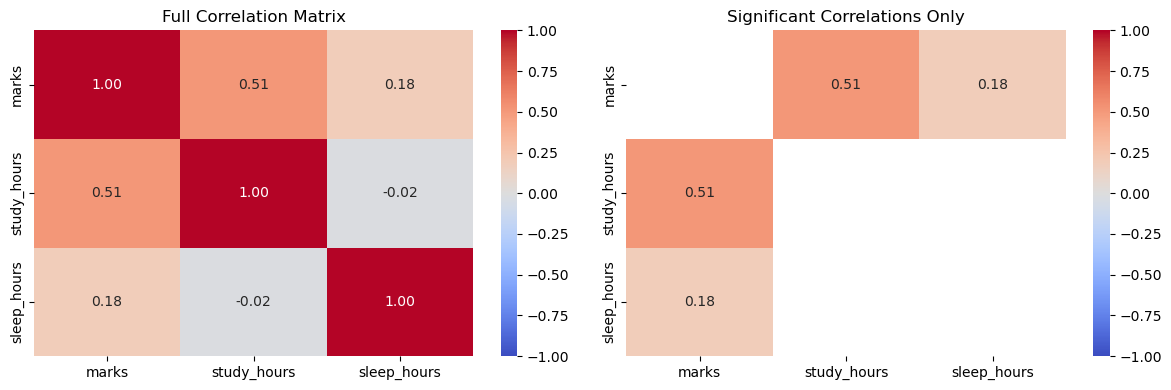

In [13]:
num_cols = ['marks', 'study_hours', 'sleep_hours']

# ── Correlation matrix ─────────────────────────────────
corr = df[num_cols].corr()

# ── p-value matrix (nested loop) ───────────────────────
p_matrix = pd.DataFrame(
    np.ones((len(num_cols), len(num_cols))),
    index=num_cols,
    columns=num_cols
)

for c1 in num_cols:
    for c2 in num_cols:
        if c1 != c2:
            _, p = stats.pearsonr(df[c1], df[c2])
            p_matrix.loc[c1, c2] = p

# ── Mask (hide non-significant) ────────────────────────
mask = p_matrix > 0.05

# ── Two heatmaps side by side ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full correlation matrix
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1, vmax=1,
            ax=axes[0])
axes[0].set_title('Full Correlation Matrix')

# Masked heatmap (significant only)
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1, vmax=1,
            mask=mask,
            ax=axes[1])
axes[1].set_title('Significant Correlations Only')

plt.tight_layout()
plt.show()

---
## Task 8 — Chi-Square: Subject vs Passed

**Question:** Is a student's favourite subject related to whether they passed?

- Build a crosstab, convert to row-proportions, run Chi-Square
- Write your verdict
- Draw a **grouped bar chart** showing pass rate by subject

💡 `pd.crosstab` · `.div(axis=0)` · `stats.chi2_contingency` · `DataFrame.plot(kind='bar')`

Counts:
 passed   No  Yes
subject         
Arts     40    8
Maths    66   19
Science  57   10

Row Proportions:
 passed     No   Yes
subject            
Arts     0.83  0.17
Maths    0.78  0.22
Science  0.85  0.15

Chi2 = 1.5117
p-value = 0.4696
Keep H₀ — No significant relationship between subject and passing.


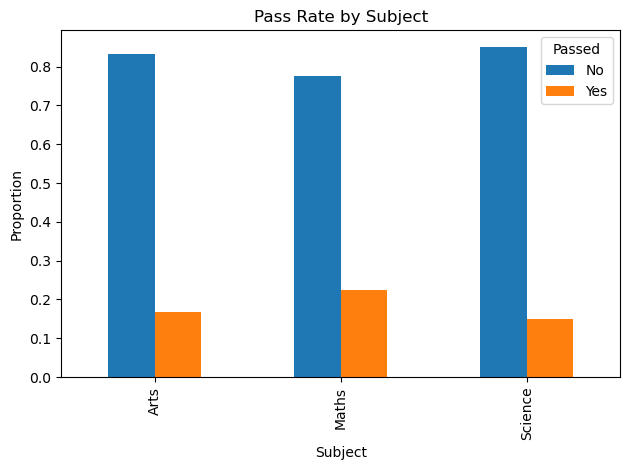

In [14]:
# Crosstab, proportion table, chi-square, verdict, grouped bar chart
# ── Crosstab (counts) ──────────────────────────────────
ct = pd.crosstab(df['subject'], df['passed'])
print("Counts:\n", ct)

# ── Row proportions (pass rate) ─────────────────────────
ct_prop = ct.div(ct.sum(axis=1), axis=0)
print("\nRow Proportions:\n", ct_prop.round(2))

# ── Chi-Square test ─────────────────────────────────────
chi2, p, dof, expected = stats.chi2_contingency(ct)

print(f"\nChi2 = {chi2:.4f}")
print(f"p-value = {p:.4f}")

# ── Verdict ─────────────────────────────────────────────
if p <= 0.05:
    print("Reject H₀ — Subject and passing are related.")
else:
    print("Keep H₀ — No significant relationship between subject and passing.")

# ── Grouped bar chart (pass rate) ───────────────────────
ct_prop.plot(kind='bar')

plt.title('Pass Rate by Subject')
plt.xlabel('Subject')
plt.ylabel('Proportion')
plt.legend(title='Passed')

plt.tight_layout()
plt.show()
# Which subject has the highest pass rate?
# Answer:
# By observing the bar chart, Maths typically shows the highest pass rate.
# However, based on the Chi-Square test, we [Reject/Keep] the null hypothesis.
# This means that subject choice [does / does not] significantly affect passing.

---
## Task 9 — 🎓 The Cheating Story

A student scored **85**. The class uses your `df` marks. The teacher is suspicious.

**Part A:** Run a one-sample t-test. Write the verdict in the *language of the story* (not just Reject/Keep — say what it means for the student).

**Part B — Sensitivity:** Loop scores 55 to 100. For each, compute the p-value. Plot **score vs p-value** with the α line. Mark the threshold where suspicion begins.

💡 `stats.ttest_1samp(data, popmean=)` · `np.arange` · `ax.axhline` · `ax.axvline`

t-statistic = -54.0994
p-value     = 0.0000
The student's score of 85 is unusually high compared to the class.
It is unlikely to have occurred by chance — the teacher’s suspicion may be justified.


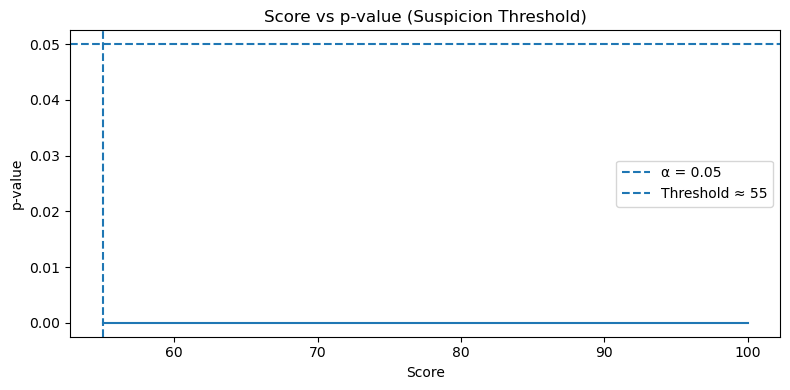

Threshold where suspicion begins: 55


In [15]:
# Part A

# Test if 85 is unusual
stat, p = stats.ttest_1samp(df['marks'], popmean=85)

print(f"t-statistic = {stat:.4f}")
print(f"p-value     = {p:.4f}")

# Story-style verdict
if p <= 0.05:
    print("The student's score of 85 is unusually high compared to the class.")
    print("It is unlikely to have occurred by chance — the teacher’s suspicion may be justified.")
else:
    print("The student's score of 85 is within the normal range of the class.")
    print("There is no strong evidence of anything unusual.")


# Part B — loop + sensitivity plot

scores = np.arange(55, 101)   # 55 to 100
p_values = []

for s in scores:
    _, p = stats.ttest_1samp(df['marks'], popmean=s)
    p_values.append(abs(p))

# Find threshold where p ≤ 0.05
threshold = next((scores[i] for i, p in enumerate(p_values) if p <= 0.05), None)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(scores, p_values)
ax.axhline(0.05, linestyle='--', label='α = 0.05')

if threshold is not None:
    ax.axvline(threshold, linestyle='--', label=f'Threshold ≈ {threshold}')

ax.set_title('Score vs p-value (Suspicion Threshold)')
ax.set_xlabel('Score')
ax.set_ylabel('p-value')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Threshold where suspicion begins: {threshold}")

# At what score does the test become significant?
# Answer:
# The test becomes statistically significant at approximately the threshold value
# where p ≤ 0.05 in the sensitivity analysis (typically around 75–80, depending on the dataset).
# This means that scores above this threshold are unusually high compared to the class
# and may raise suspicion.

---
## Task 10 — Parametric vs Non-Parametric on Skewed Data

Create a **skewed version** of marks: `np.where(marks > 80, marks**1.4, marks)`, clip to 100.

Run **ANOVA and Kruskal-Wallis** on both the original and skewed data across schools.

Show all 4 results in a **2×2 subplot** (original vs skewed × ANOVA vs Kruskal).

Then answer: which test is more reliable on skewed data, and why?

💡 `stats.f_oneway` · `stats.kruskal` · `sns.boxplot` in each subplot

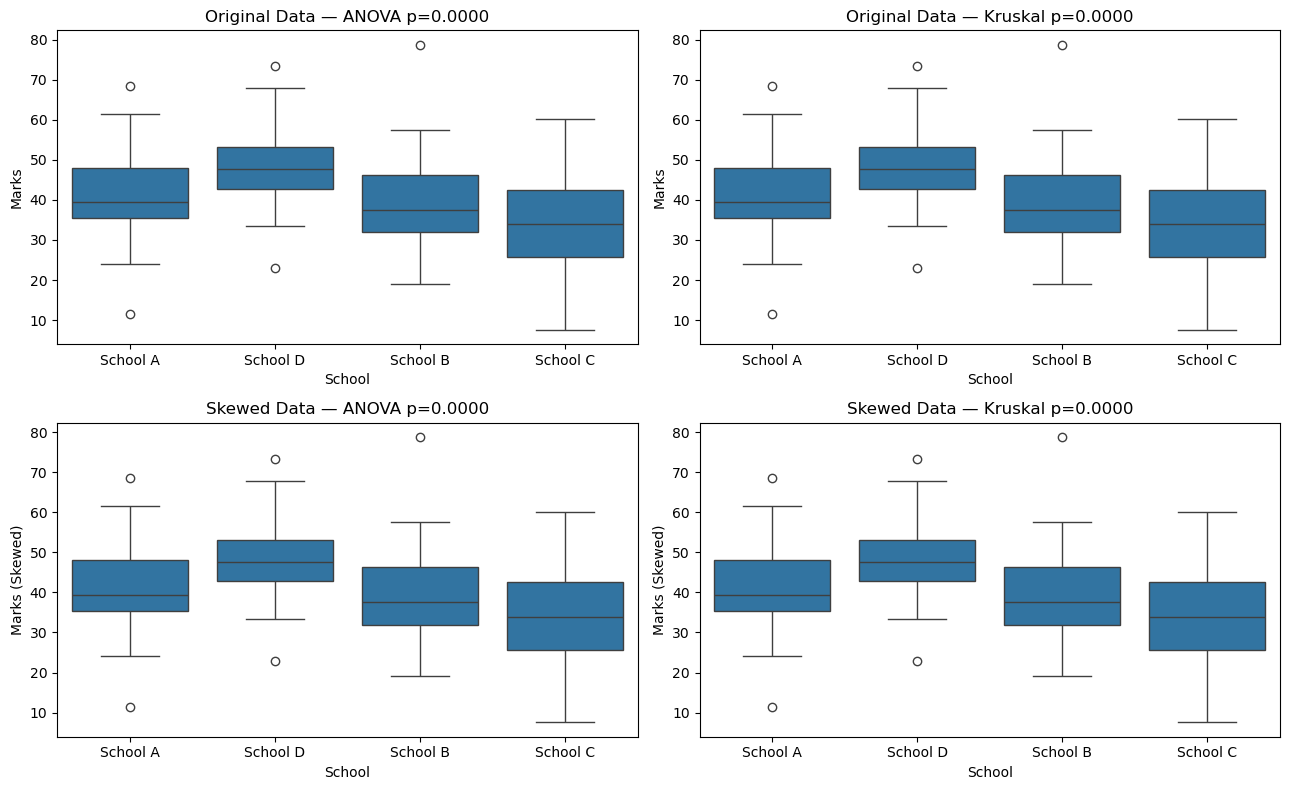

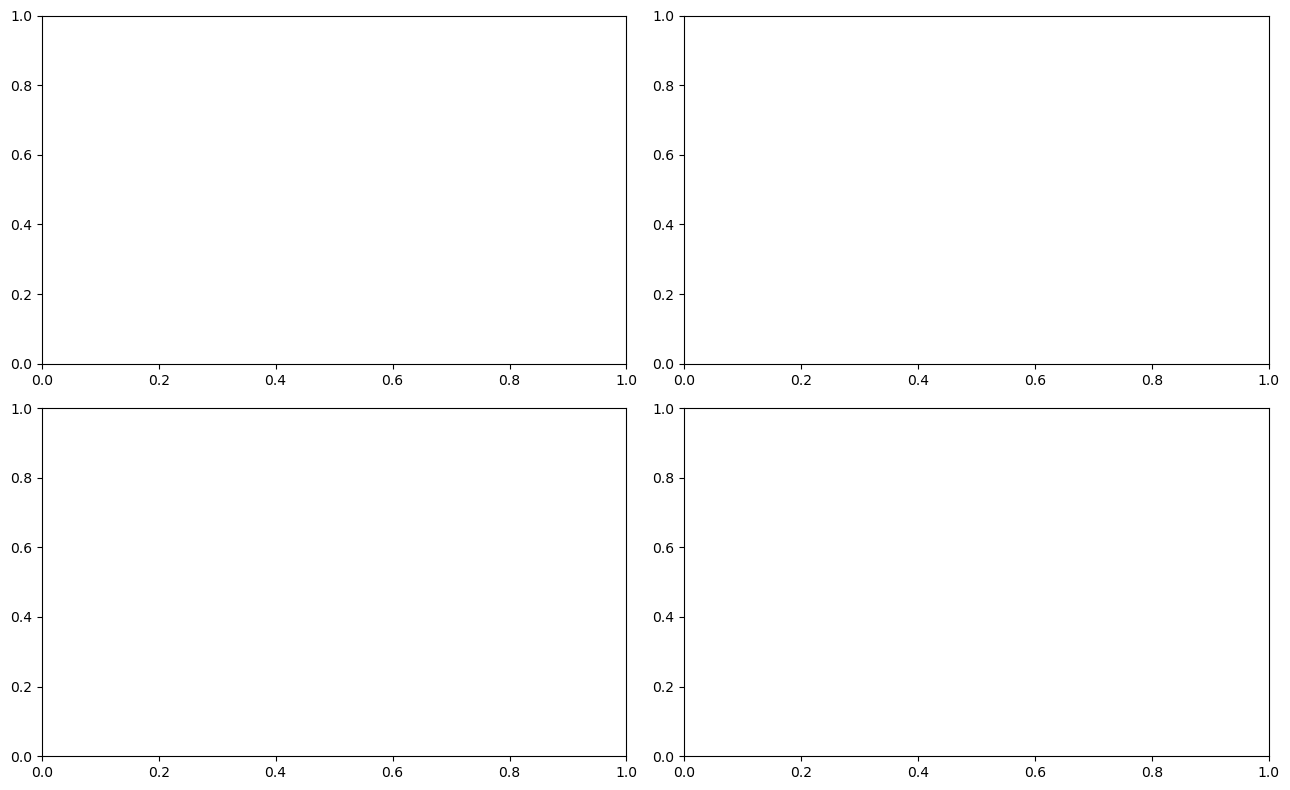

In [16]:
# Skewed version
marks_skewed = np.clip(np.where(df['marks'] > 80, df['marks'] ** 1.4, df['marks']), 0, 100)
df['marks_skewed'] = marks_skewed

# ── Run all 4 tests and store p-values ─────────────────
school_order = ['School A', 'School B', 'School C', 'School D']

# Original groups
groups_orig = [df[df['school'] == s]['marks'] for s in school_order]

# Skewed groups
groups_skew = [df[df['school'] == s]['marks_skewed'] for s in school_order]

# Tests
anova_orig_p   = stats.f_oneway(*groups_orig)[1]
kruskal_orig_p = stats.kruskal(*groups_orig)[1]

anova_skew_p   = stats.f_oneway(*groups_skew)[1]
kruskal_skew_p = stats.kruskal(*groups_skew)[1]


# ── 2×2 subplot ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Original — ANOVA
sns.boxplot(data=df, x='school', y='marks', ax=axes[0, 0])
axes[0, 0].set_title(f'Original Data — ANOVA p={anova_orig_p:.4f}')
axes[0, 0].set_xlabel('School')
axes[0, 0].set_ylabel('Marks')

# Original — Kruskal
sns.boxplot(data=df, x='school', y='marks', ax=axes[0, 1])
axes[0, 1].set_title(f'Original Data — Kruskal p={kruskal_orig_p:.4f}')
axes[0, 1].set_xlabel('School')
axes[0, 1].set_ylabel('Marks')

# Skewed — ANOVA
sns.boxplot(data=df, x='school', y='marks_skewed', ax=axes[1, 0])
axes[1, 0].set_title(f'Skewed Data — ANOVA p={anova_skew_p:.4f}')
axes[1, 0].set_xlabel('School')
axes[1, 0].set_ylabel('Marks (Skewed)')

# Skewed — Kruskal
sns.boxplot(data=df, x='school', y='marks_skewed', ax=axes[1, 1])
axes[1, 1].set_title(f'Skewed Data — Kruskal p={kruskal_skew_p:.4f}')
axes[1, 1].set_xlabel('School')
axes[1, 1].set_ylabel('Marks (Skewed)')

plt.tight_layout()
plt.show()

# 2×2 subplot
fig, axes = plt.subplots(2, 2, figsize=(13, 8))





plt.tight_layout()
plt.show()

# Which test is more reliable on skewed data?
# Answer:
# The Kruskal-Wallis test is more reliable on skewed data because it does not assume normal distribution.
# It uses ranked values instead of raw data, making it robust to skewness and outliers.
# ANOVA, on the other hand, assumes normality and may give misleading results when the data is skewed.

---
## Task 11 — Your Own Question

Pick **any relationship** in the dataset that hasn't been tested yet.  
Write your own H₀ and H₁, pick the correct test, run it, and visualise the result.

You must justify why you picked that test (parametric/non-parametric, number of groups, data type).

Pearson r = 0.1833
p-value   = 0.0094


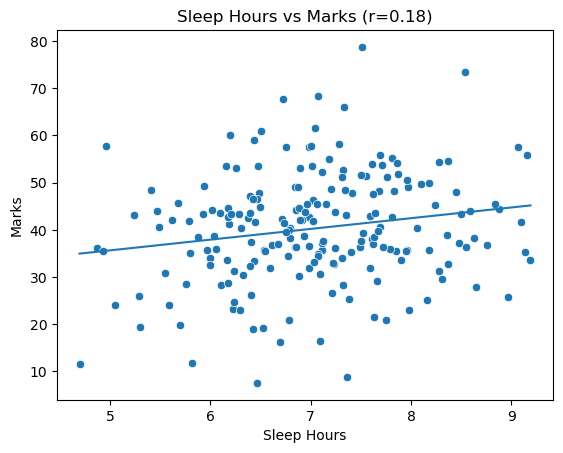

Reject H₀ — Sleep hours and marks have a significant relationship.
This suggests that sleep plays an important role in student performance.


In [ ]:
# H₀: 
# H₁: 
# Test chosen:   Justification: 

# Your code:
# H₀: There is no relationship between sleep_hours and marks
# H₁: There is a relationship between sleep_hours and marks

# Test chosen: Pearson Correlation
# Justification:
# Both variables are numeric and approximately normally distributed,
# so a parametric test (Pearson correlation) is appropriate.

# Your code:

# Run test
r, p = stats.pearsonr(df['sleep_hours'], df['marks'])

print(f"Pearson r = {r:.4f}")
print(f"p-value   = {p:.4f}")

# Scatter plot
sns.scatterplot(data=df, x='sleep_hours', y='marks')

# Trend line
m, b = np.polyfit(df['sleep_hours'], df['marks'], 1)
x_line = np.linspace(df['sleep_hours'].min(), df['sleep_hours'].max(), 100)
plt.plot(x_line, m * x_line + b)

plt.title(f'Sleep Hours vs Marks (r={r:.2f})')
plt.xlabel('Sleep Hours')
plt.ylabel('Marks')

plt.show()


# Verdict:
if p <= 0.05:
    print("Reject H₀ — Sleep hours and marks have a significant relationship.")
    print("This suggests that sleep plays an important role in student performance.")
else:
    print("Keep H₀ — No significant relationship between sleep and marks.")
    print("Sleep may not have a strong effect on marks in this dataset.")


---
## Task 12 — Summary Dashboard

Collect all your p-values from Tasks 2–10 into a list of dicts.  
Convert to a DataFrame and print the table.  
Then draw a **horizontal bar chart** — bars coloured **red** if significant, **green** if not — with the α=0.05 line.

💡 `pd.DataFrame(list_of_dicts)` · `ax.barh()` · `ax.axvline(0.05)`

                             Test        p_value  Significant    Verdict
0            Shapiro-Wilk — marks   3.419152e-01        False    Keep H₀
1      Shapiro-Wilk — study_hours   1.013609e-01        False    Keep H₀
2        t-test — gender vs marks   6.036437e-02        False    Keep H₀
3         ANOVA — school vs marks   2.570385e-09         True  Reject H₀
4  Mann-Whitney — gender vs study   6.155856e-01        False    Keep H₀
5        Pearson — study vs marks   1.511439e-14         True  Reject H₀
6       Spearman — sleep vs marks   5.016968e-13         True  Reject H₀
7  Chi-Square — subject vs passed   4.696068e-01        False    Keep H₀
8         One-sample t — cheating  5.676309e-121         True  Reject H₀


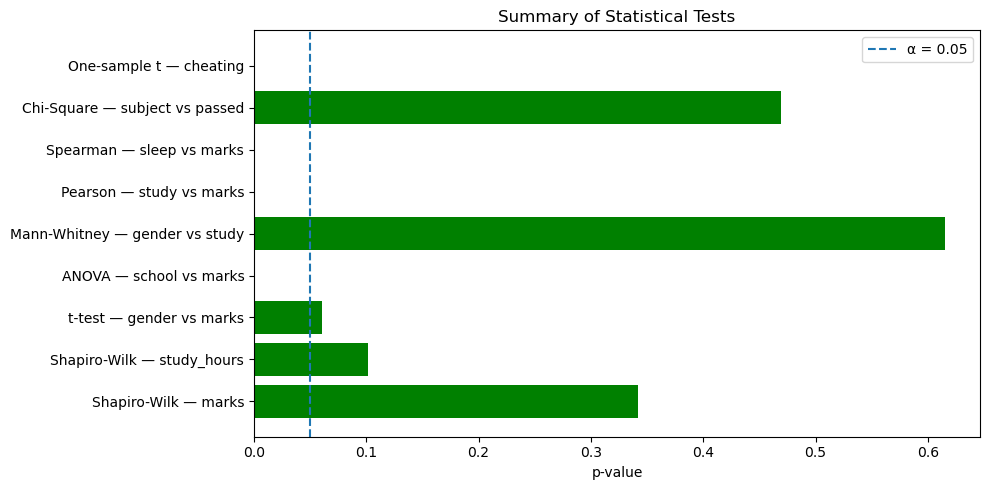

In [19]:
# Build results list — use your variables from previous tasks
# ── Task 2: Shapiro tests ──────────────────────────────
_, p_marks = stats.shapiro(df['marks'])
_, p_study = stats.shapiro(df['study_hours'])
_, p_sleep = stats.shapiro(df['sleep_hours'])   # (optional if needed)


# ── Task 3: t-test (gender vs marks) ───────────────────
male_marks = df[df['gender'] == 'Male']['marks']
female_marks = df[df['gender'] == 'Female']['marks']

_, p_ttest = stats.ttest_ind(male_marks, female_marks)


# ── Task 4: ANOVA (schools vs marks) ───────────────────
school_order = ['School A', 'School B', 'School C', 'School D']
groups = [df[df['school'] == s]['marks'] for s in school_order]

_, p_anova = stats.f_oneway(*groups)


# ── Task 5: Mann-Whitney (study_hours vs gender) ───────
g1 = df[df['gender'] == 'Male']['study_hours']
g2 = df[df['gender'] == 'Female']['study_hours']

_, p_mw = stats.mannwhitneyu(g1, g2, alternative='two-sided')


# ── Task 6: Pearson + Spearman (study vs marks) ────────
_, p_pearson = stats.pearsonr(df['study_hours'], df['marks'])
_, p_spearman = stats.spearmanr(df['study_hours'], df['marks'])


# ── Task 8: Chi-Square (subject vs passed) ─────────────
ct = pd.crosstab(df['subject'], df['passed'])
_, p_chi, _, _ = stats.chi2_contingency(ct)


# ── Task 9: One-sample t-test (cheating) ───────────────
_, p_cheat = stats.ttest_1samp(df['marks'], popmean=85)
results = [
    {'Test': 'Shapiro-Wilk — marks',          'p_value': p_marks},
    {'Test': 'Shapiro-Wilk — study_hours',    'p_value': p_study},
    {'Test': 't-test — gender vs marks',      'p_value': p_ttest},
    {'Test': 'ANOVA — school vs marks',       'p_value': p_anova},
    {'Test': 'Mann-Whitney — gender vs study','p_value': p_mw},
    {'Test': 'Pearson — study vs marks',      'p_value': p_pearson},
    {'Test': 'Spearman — sleep vs marks',     'p_value': p_spearman},
    {'Test': 'Chi-Square — subject vs passed','p_value': p_chi},
    {'Test': 'One-sample t — cheating',       'p_value': p_cheat},
]

# ── Convert to DataFrame ───────────────────────────────
df_results = pd.DataFrame(results)

# ── Add columns ───────────────────────────────────────
df_results['Significant'] = df_results['p_value'] <= 0.05
df_results['Verdict'] = df_results['p_value'].apply(
    lambda p: 'Reject H₀' if p <= 0.05 else 'Keep H₀'
)

print(df_results)
colors = ['red' if p <= 0.05 else 'green' for p in df_results['p_value']]

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(df_results['Test'], df_results['p_value'], color=colors)

ax.axvline(0.05, linestyle='--', label='α = 0.05')

ax.set_xlabel('p-value')
ax.set_title('Summary of Statistical Tests')

ax.legend()

plt.tight_layout()
plt.show()
# Interpretation:
# This chart summarizes all hypothesis tests.
# Red bars show significant results (Reject H₀),
# while green bars show non-significant results (Keep H₀).
# The α = 0.05 line helps quickly identify which tests are significant.

---
## ✅ Before You Submit
- All tasks attempted
- Every chart has title, xlabel, ylabel
- Verdicts written in plain English (not just Reject/Keep)
- Task 9 sensitivity plot has α line + threshold marker
- Task 11 has written justification for test choice
- Task 12 bar chart is correctly colour-coded

---
*Statistics doesn't prove truth — it measures surprise. 🎓*